# C08 · Code walkthrough: `aerodynamics/` (simple, Scholz, AeroBuildup, blown wing, trim, download)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). Modules are taken bottom-up in import order. Each "Run it" cell runs the code on the sized Halo
(the cached v3.6 baseline) and checks the claims made in the text.

| Module | Lines | What it holds | Imports from the package |
|---|---|---|---|
| `aerodynamics/__init__.py` | 1 | docstring only | none |
| `aerodynamics/simple.py` | 140 | `DragIncrement`, `ParasiteDragItem`, `AeroResult`; `SimpleAerodynamics` (linear lift, Raymer parasite build-up, Nita-Scholz Oswald) | none |
| `aerodynamics/download.py` | 47 | `HoverDownload`, `download_fraction`, `hover_download_fraction` (NDARC download form) | none |
| `aerodynamics/scholz.py` | 185 | Scholz ch. 13 closed forms, `InterferenceFactors`, `ScholzAerodynamics` (the hand check) | `simple`, `download` |
| `aerodynamics/slipstream.py` | 88 | `RotorState`, `BlownWingIncrement`, `BlownWing` (momentum-theory blown wing) | none |
| `aerodynamics/trim.py` | 67 | `TailTrim` (trim drag from the tail load about the CG) | none |
| `aerodynamics/buildup.py` | 210 | `TransitionAirfoil`, `BuildupResult`, `BuildupAerodynamics` (AeroBuildup plus the added items) | `simple`, `scholz`, `download` |

**Who imports them (grep of `src/`, `examples/`):**
- `simple.SimpleAerodynamics`: `examples/halo_sizing.py`, `cruise_closure.py`, `coupled_sizing.py`,
  `mission_analysis.py`, `requirements_sizing.py`, `tail_sizing.py`. `simple.DragIncrement`: `controls/stability.py`.
- `slipstream.RotorState`: `performance/flight_point.py`. `slipstream.BlownWing`, `trim.TailTrim`,
  `buildup.BuildupAerodynamics`, `scholz.ScholzAerodynamics`: `examples/halo_sizing.py` (`build_halo_aerodynamics`).
- Everything else reaches the models through duck typing: `performance/flight_point.py`,
  `trajectory/tiltrotor.py`, `trajectory/corridor.py` and `controls/stability.py` call `evaluate`,
  `alpha_stall_deg`, `hover_download_fraction`, `lift_curve_slope_per_rad`, `surface_lift_curve_slope_per_rad`
  on whatever model they are given. There is no base class. The three models are interchangeable by convention.

**What the package imports:** only AeroSandbox (`asb`, `aerosandbox.numpy`, library functions). The discipline imports
no vehicle module: geometry comes in as the `aircraft` argument (`aircraft.wing`, `.to_asb()`, ...).

Design log: plan 006 (simple aero), 025 (AeroBuildup, Scholz, blown wing, download), 027 (AeroBuildup is the Halo
reference), 034 (excrescence, flat trim), 035 (corrections on by default), 036 (trim from the tail load).

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft, build_halo_aerodynamics
from aircraft_closure.aerodynamics.slipstream import RotorState
from aircraft_closure.performance.flight_point import acceleration_gravity_m_s2

ref = baseline()
requirements, assumptions = HaloRequirements(), baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
aero_halo = build_halo_aerodynamics(requirements, assumptions)        # BuildupAerodynamics (the reference)

# The sized cruise point. The cruise segment is split into 4 subsegments; the result reports the first one,
# which starts at take-off mass minus the take-off hover and climb fuel.
segments = {s["label"]: s for s in ref.segments}
mass_cruise_kg = ref.mass_takeoff_kg - segments["take-off hover"]["fuel_kg"] - segments["climb"]["fuel_kg"]
weight_N = mass_cruise_kg * acceleration_gravity_m_s2
velocity_m_s = segments["cruise"]["velocity_m_s"]
altitude_m = segments["cruise"]["altitude_start_m"]
speed_rotor_rad_s = next(w["speed_rotor_rad_s"] for w in ref.whirl_flutter if w["label"] == "cruise 1/4")
drag_cooling_N = next(t["drag_cooling_N"] for t in ref.thermal_trace if t["label"] == "cruise 1/4")
propulsor = aircraft.powertrain.topology.instances["propulsor"]
print(f"mass {mass_cruise_kg:.1f} kg, V {velocity_m_s:.2f} m/s ({velocity_m_s / u.knot:.1f} kt), "
      f"h {altitude_m:.0f} m, rotor {speed_rotor_rad_s:.2f} rad/s, cooling drag {drag_cooling_N:.2f} N")
print(f"wing S {aircraft.wing.area_m2:.3f} m2, AR {aircraft.wing.aspect_ratio}, b {aircraft.wing.span_m():.3f} m; "
      f"{propulsor.count} rotors, disk {propulsor.component.area_disk_m2:.2f} m2 each")
print(f"sized cruise: L/D {ref.lift_to_drag_cruise:.4f}, CL {ref.cl_cruise:.4f}")

mass 6824.0 kg, V 85.13 m/s (165.5 kt), h 3048 m, rotor 29.36 rad/s, cooling drag 2.94 N
wing S 23.299 m2, AR 6.12, b 11.941 m; 2 rotors, disk 73.36 m2 each
sized cruise: L/D 9.0653, CL 0.8779


---
## 1. `aerodynamics/simple.py`

The first model (plan 006) and still the template of the interface. Read it first: the other two copy its method
names and its `AeroResult`.

In [2]:
show_source("src/aircraft_closure/aerodynamics/simple.py", 1, 54)

# src/aircraft_closure/aerodynamics/simple.py  lines 1-54
   1  """Simple analytic aerodynamics: linear lift, parasite buildup, induced drag.
   2  
   3  Geometry is read from the physical components (`wing`, `horizontal_tail`,
   4  `vertical_tail`, `fuselage`, each with `to_asb()`); this discipline imports no
   5  vehicle module. AeroSandbox supplies skin friction, the 3D lift-slope ratio,
   6  Oswald efficiency and the fuselage form factor. Wing lift only: tail lift and
   7  trim belong to Tier 6. Valid for attached flow below the stated CLmax and
   8  cruise Mach below about 0.3.
   9  """
  10  from dataclasses import dataclass
  11  from typing import Any
  12  
  13  import aerosandbox as asb
  14  import aerosandbox.numpy as np
  15  from aerosandbox.aerodynamics.aero_3D.aero_buildup_submodels.fuselage_aerodynamics_utilities import (
  16      fuselage_form_factor)
  17  from aerosandbox.library.aerodynamics.inviscid import CL_over_Cl, oswalds_efficiency
  18  from aerosan

**Line by line**

- **L1-8 docstring**: the contract. Geometry belongs to the vehicle components (each has `to_asb()`); this module
  imports no vehicle class. Wing lift only (no tail lift), valid in attached flow and below about Mach 0.3.
- **L13-18 imports**: AeroSandbox supplies four pieces: `fuselage_form_factor` (the body form factor AeroBuildup
  itself uses), `CL_over_Cl` (3D/2D lift-slope ratio, Raymer/DATCOM with a smoothed Prandtl-Glauert factor),
  `oswalds_efficiency` (Nita-Scholz) and `Cf_flat_plate` (default method "hybrid-sharpe-convex": a softmax of the
  laminar Blasius 1.328/sqrt(Re) and Schlichting's 0.02666 Re^-0.139, so it is smooth through transition).
- **L21-25 `DragIncrement(label, cd)`**: an extra drag coefficient on the wing area that a *caller* adds. The only
  producer is `controls/stability.py` L104 (the Tier 6 tail-trim induced drag, used by `examples/tail_sizing.py`).
  `flight_point.build_flight_point(..., drag_increments=())` forwards them; the Halo sizing passes none.
- **L28-31 `ParasiteDragItem(label, cd0)`**: one line of the parasite drag breakdown, on the wing reference area.
  Shared by all three models so reports look the same.
- **L34-47 `AeroResult`**: the one output type of `evaluate` in all three models. Coefficients (cl, cd, cd0, cdi),
  slope, Oswald factor, q, Mach, dimensional lift and drag, L/D. All fields are `Any`: floats, numpy arrays or
  CasADi expressions.
- **L50-53 `_surface_form_factor`**: Raymer eq. 12.30 for an unswept surface,

$$FF = \left[1 + \frac{0.6}{(x/c)_m}\frac{t}{c} + 100\left(\frac{t}{c}\right)^4\right]\cdot 1.34\,M^{0.18}$$

  with (x/c)_m the chordwise position of maximum thickness. The Mach factor 1.34 M^0.18 is below 1 for M < 0.197 and
  goes to 0 at M = 0. This is the same expression as `scholz.form_factor_surface` (scholz L41-44), written twice.

In [3]:
show_source("src/aircraft_closure/aerodynamics/simple.py", 55, 103)

# src/aircraft_closure/aerodynamics/simple.py  lines 55-103
  55  
  56  @dataclass(frozen=True)
  57  class SimpleAerodynamics:
  58      alpha_zero_lift_deg: Any = -4.0
  59      cl_max: Any = 1.5
  60      thickness_location_chordwise: Any = 0.3
  61      interference_wing: Any = 1.0
  62      interference_tail: Any = 1.05
  63      interference_fuselage: Any = 1.0
  64      drag_area_misc_m2: Any = 0.25
  65      # Fraction of hover rotor thrust lost to airframe download (wing under the
  66      # rotor wake); XV-15: 0.07 with flaps deflected (NASA TM X-62407 sec. 5.1).
  67      download_fraction_hover: Any = 0.0
  68  
  69      def hover_download_fraction(self, aircraft):
  70          """A constant fraction (Tier 10b); `BuildupAerodynamics` and `ScholzAerodynamics` can use geometry."""
  71          return self.download_fraction_hover
  72  
  73      # `temperature_offset_K` (Tier 16): ambient minus ISA temperature at the pressure altitude; 0 = standard day.
  74      def _fl

- **L56-67 constructor = assumptions**: zero-lift angle -4 deg (cambered section), CLmax 1.5, (x/c)_m 0.3,
  interference Q (wing 1.0, tails 1.05, fuselage 1.0), a miscellaneous drag area 0.25 m2, and a constant hover
  download fraction (0 here; 0.07 in the Halo "simple" sets, from the XV-15, NASA TM X-62407 sec. 5.1).
  `frozen=True`: the model is a value; changing an assumption means `replace(...)`.
- **L69-71 `hover_download_fraction(aircraft)`**: returns the constant. The `aircraft` argument is unused here; it
  exists so the flight point can call all three models the same way (the other two use geometry).
- **L74-78 `_flow`**: the ISA atmosphere with an optional temperature offset (Tier 16 hot day), returning
  density (kg/m3), dynamic viscosity (Pa s), Mach and q = 0.5 rho V^2 (Pa). All `aerosandbox.numpy`, so V and h may be
  Opti expressions.
- **L80-103 `parasite_drag_breakdown`**: component build-up on S_ref = the asb wing area (L82-83):

$$C_{D0,c} = C_f(Re_c)\; FF_c\; Q_c\; \frac{S_{wet,c}}{S_{ref}}$$

  - **L85-91 `surface`**: Reynolds on the mean aerodynamic chord (L86-87); thickness = the *minimum* t/c over the
    cross-sections (L88; one airfoil per surface in practice); wetted area from AeroSandbox (`area("wetted")`).
  - **L93-95, L100-101 fuselage**: Reynolds on the length; fineness ratio l / d_eq with d_eq the geometric-mean
    diameter of the boxy section (`fuselage.diameter_equivalent_m()`); AeroSandbox's body form factor; wetted area of
    the AeroSandbox fuselage.
  - **L102 miscellaneous**: drag area / S_ref.
  - Nacelles are not in this model's breakdown: they are covered by the misc. drag area (0.8 m2 in the Halo simple
    sets, "tip nacelles, spinners, gear fairings").

In [4]:
show_source("src/aircraft_closure/aerodynamics/simple.py", 104, 140)

# src/aircraft_closure/aerodynamics/simple.py  lines 104-140
 104  
 105      def surface_lift_curve_slope_per_rad(self, aspect_ratio, velocity_m_s, altitude_m, temperature_offset_K=0.0):
 106          """Finite-surface slope 2 pi CL_over_Cl(AR, M); also used for the tails (Tier 6)."""
 107          _, _, mach, _ = self._flow(velocity_m_s, altitude_m, temperature_offset_K)
 108          return 2 * np.pi * CL_over_Cl(aspect_ratio, mach=mach)
 109  
 110      def lift_curve_slope_per_rad(self, aircraft, velocity_m_s, altitude_m, temperature_offset_K=0.0):
 111          return self.surface_lift_curve_slope_per_rad(aircraft.wing.aspect_ratio, velocity_m_s, altitude_m,
 112                                                       temperature_offset_K)
 113  
 114      def oswald_efficiency(self, aircraft):
 115          wing = aircraft.wing
 116          return oswalds_efficiency(wing.taper_ratio, wing.aspect_ratio,
 117                                    fuselage_diameter_to_span_ratio=aircra

- **L105-108 `surface_lift_curve_slope_per_rad(AR, V, h)`**: a = 2 pi CL_over_Cl(AR, M). Takes an aspect ratio,
  not a surface, so `controls/stability.py` uses it for the tails and the fin (Tier 6).
- **L110-112 `lift_curve_slope_per_rad(aircraft, ...)`**: the same for the wing.
- **L114-117 `oswald_efficiency`**: Nita-Scholz through AeroSandbox with the fuselage factor k_e,F = 1 - 2 (d_F/b)^2.
  `diameter_m` is the section *width* (1.68 m for the Halo), not the equivalent diameter.
- **L119-123 `alpha_stall_deg`**: linear lift reaches CLmax at

$$\alpha_{stall} = \alpha_{0L} + \frac{180}{\pi}\frac{C_{L,max}}{a}$$

  The flight point writes it as an upper bound on alpha. The `aero` argument is accepted and ignored (L120-121) so
  the call signature matches `BuildupAerodynamics`.
- **L125-140 `evaluate`**: CL = a (alpha - alpha_0L) in radians (L130); CD0 from the breakdown (L132-133); induced

$$C_{Di} = \frac{C_L^2}{\pi\, e\, AR}$$

  (L134); CD = CD0 + CDi + caller increments (L135). Forces on `aircraft.wing.area_m2` (L136-139). `rotor_state` is
  accepted and unused (L127).

**Run it**: the simple model at the sized cruise point, with the misc. area of the Halo "simple" sets.

In [5]:
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics, _surface_form_factor
from aircraft_closure.aerodynamics.scholz import form_factor_surface

simple = build_halo_aerodynamics(requirements, replace(assumptions, aerodynamics_model="simple"))
print(simple)
for item in simple.parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m):
    print(f"  {item.label:<16} CD0 {scalar(item.cd0):.5f}")

# alpha for lift = weight is closed form for linear lift
_, _, mach, q_Pa = simple._flow(velocity_m_s, altitude_m)
slope = scalar(simple.lift_curve_slope_per_rad(aircraft, velocity_m_s, altitude_m))
cl_needed = weight_N / (scalar(q_Pa) * aircraft.wing.area_m2)
alpha_simple = simple.alpha_zero_lift_deg + np.degrees(cl_needed / slope)
r = simple.evaluate(aircraft, velocity_m_s, altitude_m, alpha_simple)
print(f"M {scalar(mach):.3f}, q {scalar(q_Pa):.0f} Pa, a {slope:.3f} /rad, alpha {alpha_simple:.3f} deg, "
      f"CL {scalar(r.cl):.4f}, CD0 {scalar(r.cd0):.4f}, CDi {scalar(r.cdi):.4f}, e {scalar(r.oswald_efficiency):.3f}, "
      f"L/D {scalar(r.lift_to_drag):.2f}")

check("lift = weight at the closed-form alpha", abs(scalar(r.lift_N) / weight_N - 1) < 1e-12)
check("CL(alpha_0L) = 0", abs(scalar(simple.evaluate(aircraft, velocity_m_s, altitude_m, -4.0).cl)) < 1e-12)
check("CD - CD0 = CL^2 / (pi e AR)", abs(scalar(r.cd - r.cd0 - r.cl**2 / (np.pi * r.oswald_efficiency
                                                                        * aircraft.wing.aspect_ratio))) < 1e-12)
alpha_stall = scalar(simple.alpha_stall_deg(aircraft, velocity_m_s, altitude_m))
check("CL(alpha_stall) = CLmax", abs(scalar(simple.evaluate(aircraft, velocity_m_s, altitude_m, alpha_stall).cl)
                                     - simple.cl_max) < 1e-12)
check("simple._surface_form_factor is scholz.form_factor_surface (duplicate code)",
      all(_surface_form_factor(t, 0.3, m) == form_factor_surface(t, 0.3, m) for t in (0.09, 0.15, 0.23)
          for m in (0.1, 0.26)))
print("Mach factor 1.34 M^0.18 at M = 0.05, 0.1, 0.197, 0.26:",
      [round(1.34 * m**0.18, 3) for m in (0.05, 0.1, 0.197, 0.26)])

# symbolic: the same call inside an Opti, alpha as a variable
opti = asb.Opti()
alpha = opti.variable(init_guess=2.0)
opti.subject_to(simple.evaluate(aircraft, velocity_m_s, altitude_m, alpha).lift_N == weight_N)
check("Opti finds the same alpha", abs(opti.solve(verbose=False)(alpha) - alpha_simple) < 1e-8)

SimpleAerodynamics(alpha_zero_lift_deg=-4.0, cl_max=1.5, thickness_location_chordwise=0.3, interference_wing=1.0, interference_tail=1.05, interference_fuselage=1.0, drag_area_misc_m2=0.8, download_fraction_hover=0.07)
  wing             CD0 0.01151
  horizontal_tail  CD0 0.00217
  vertical_tail    CD0 0.00100
  fuselage         CD0 0.00592
  miscellaneous    CD0 0.03434
M 0.259, q 3272 Pa, a 4.508 /rad, alpha 7.158 deg, CL 0.8779, CD0 0.0549, CDi 0.0523, e 0.766, L/D 8.19
PASS  lift = weight at the closed-form alpha
PASS  CL(alpha_0L) = 0
PASS  CD - CD0 = CL^2 / (pi e AR)
PASS  CL(alpha_stall) = CLmax
PASS  simple._surface_form_factor is scholz.form_factor_surface (duplicate code)
Mach factor 1.34 M^0.18 at M = 0.05, 0.1, 0.197, 0.26: [0.781, 0.885, 1.0, 1.051]
PASS  Opti finds the same alpha


---
## 2. `aerodynamics/download.py`

In [6]:
show_source("src/aircraft_closure/aerodynamics/download.py")

# src/aircraft_closure/aerodynamics/download.py  lines 1-47
   1  """Hover download from wing and rotor geometry (Tier 21, plan 025).
   2  
   3  NDARC form (Johnson, "NDARC Validation and Demonstration", AHS 2010): the wake reaches its fully developed
   4  velocity 2 v_h quickly below the disk, so the wake dynamic pressure is 1/2 rho (2 v_h)^2 = T / A, and
   5  
   6      DL / T = K_int C_D,v S_immersed / A_disk,
   7  
   8  with the vertical drag coefficient C_D,v set to reproduce a known download and the flap effect carried by the
   9  projected wing chord, c (1 - c_f (1 - cos delta_f)). Immersed area for tip-mounted rotors: the strip of wing
  10  under the inboard half of the contracted wake (radius R / sqrt 2), chord_projected x R / sqrt 2 per rotor.
  11  
  12  Calibration: XV-15 (wing 168.88 ft2, span 32.17 ft, rotor radius 12.5 ft; NDARC Table 1) with 7 % download with
  13  flaps (NASA TM X-62407 sec. 5.1) at the default flap setting gives C_D,v = 0.846.
  14  """
  15 

- **L1-14 docstring**: the NDARC form (Johnson 2010). The wake reaches its fully developed velocity 2 v_h a short way
  below the disk, so the wake dynamic pressure is 0.5 rho (2 v_h)^2 = 2 rho v_h^2 = T / A (because T = 2 rho A v_h^2).
  The download on the immersed wing area is then q_wake C_D,v S_imm = (T/A) C_D,v S_imm, which gives

$$\frac{DL}{T} = K_{int}\, C_{D,v}\, \frac{S_{imm}}{A_{disk}}$$

  independent of thrust and density. The flap reduces the area the wake hits: projected chord
  c (1 - c_f (1 - cos delta_f)).
- **L21-26 `HoverDownload`**: C_D,v = 0.846 (calibrated, L13-14), flap chord fraction 0.25 and hover deflection
  60 deg (both assumed), K_int = 1.
- **L29-30 `chord_projected_m`**: the flap folds c_f c down by delta_f; its horizontal projection is
  c_f c cos(delta_f).
- **L33-39 `download_fraction`**: the contracted wake radius R/sqrt(2) (area halves from disk to far wake, L35); the
  immersed strip per tip rotor is (R/sqrt 2) x projected chord (only the inboard half of the wake is over the wing;
  its spanwise extent is one wake radius) (L36-37); total disk area (L38). Both areas scale with the count, so the
  count cancels.
- **L42-47 `hover_download_fraction(aircraft)`**: the mean chord S/b and the propulsor instance's radius and count.
  This is what makes the download a design function: a bigger chord or a smaller rotor raises it.

**Run it**: reproduce the XV-15 calibration and the Halo value.

In [7]:
from aircraft_closure.aerodynamics.download import HoverDownload, chord_projected_m, download_fraction

chord_xv15_m = 168.88 * u.foot**2 / (32.17 * u.foot)
dl_xv15 = download_fraction(chord_xv15_m, 12.5 * u.foot, 2)
dl_xv15_clean = download_fraction(chord_xv15_m, 12.5 * u.foot, 2, HoverDownload(deflection_flap_hover_deg=0.0))
print(f"XV-15 DL/T: flaps 60 deg {dl_xv15:.4f}, flaps 0 deg {dl_xv15_clean:.4f}")
check("XV-15 calibration: C_D,v 0.846 gives 7 % download with flaps", abs(dl_xv15 - 0.07) < 5e-4)
check("count cancels", abs(download_fraction(2.0, 4.0, 1) - download_fraction(2.0, 4.0, 4)) < 1e-15)
check("projected chord at 60 deg flap = c (1 - 0.25 x 0.5)", abs(chord_projected_m(2.0, 0.25, 60.0) - 1.75) < 1e-12)

dl_halo = scalar(aero_halo.hover_download_fraction(aircraft))
radius_m = np.sqrt(propulsor.component.area_disk_m2 / np.pi)
print(f"Halo: mean chord {aircraft.wing.area_m2 / aircraft.wing.span_m():.3f} m, R {radius_m:.3f} m, "
      f"DL/T {dl_halo:.4f} (hover thrust = T/W x W / (1 - DL/T): +{100 * (1 / (1 - dl_halo) - 1):.2f} %)")
check("Halo download matches the formula by hand",
      abs(dl_halo - 0.846 * (radius_m / np.sqrt(2)) * chord_projected_m(aircraft.wing.area_m2 / aircraft.wing.span_m(),
                                                                       0.25, 60.0) / (np.pi * radius_m**2)) < 1e-12)

XV-15 DL/T: flaps 60 deg 0.0700, flaps 0 deg 0.0800
PASS  XV-15 calibration: C_D,v 0.846 gives 7 % download with flaps
PASS  count cancels
PASS  projected chord at 60 deg flap = c (1 - 0.25 x 0.5)
Halo: mean chord 1.951 m, R 4.832 m, DL/T 0.0673 (hover thrust = T/W x W / (1 - DL/T): +7.21 %)
PASS  Halo download matches the formula by hand


---
## 3. `aerodynamics/scholz.py`

The level-0 build-up from Scholz, *Aircraft Design* ch. 13. Its job (plan 025) is the independent hand check of
AeroBuildup, and the warm start of the AeroBuildup sizing (`_precursor_problem("scholz_aero")` in `halo_sizing.py`).

In [8]:
show_source("src/aircraft_closure/aerodynamics/scholz.py", 1, 34)

# src/aircraft_closure/aerodynamics/scholz.py  lines 1-34
   1  """Scholz level-0 drag build-up: the independent hand check of the AeroBuildup model (Tier 21, plan 025).
   2  
   3  D. Scholz, *Aircraft Design*, ch. 13 "Drag Prediction" (HAW Hamburg lecture notes):
   4  
   5      C_D0 = sum_c C_f,c FF_c Q_c S_wet,c / S_ref + C_D,misc                       (13.15)
   6  
   7  * C_f: turbulent flat plate with the Mach term (13.17). AeroSandbox's `Cf_flat_plate` has no Mach term,
   8    which is the reason this one is written here.
   9  * FF: DATCOM/Raymer surface form factor (13.22, unswept), DATCOM fuselage form factor (13.23), Raymer nacelle
  10    1 + 0.35 / (l/d) (13.24).
  11  * Q: interference factors of Table 13.4 (`InterferenceFactors`).
  12  * S_wet: Torenbeek, fuselage with a cylindrical mid-section (13.8), wing (13.10) on the exposed area.
  13  * Wave drag: Korn equation with Lock's 20 (M - M_crit)^4 (AeroSandbox `Cd_wave_Korn`, kappa_A 0.87 for
  14    conventional s

- **L1-19 docstring**: the method in one equation (13.15) and where each piece comes from. L7-8 says why this module
  writes its own Cf: AeroSandbox's `Cf_flat_plate` has no Mach term.
- **L26-27**: AeroSandbox's Nita-Scholz Oswald factor and Korn wave drag are reused.
- **L29-30**: `download` (geometric download) and `simple` (the base class and result types).
- **L32-33 `_k_e_d0_aerosandbox`**: AeroSandbox's `oswalds_efficiency` multiplies by the *mean* k_e,D0 of four aircraft
  classes (0.873, 0.864, 0.804, 0.804 → 0.83625). The constant is kept so `oswald_nita_scholz` can divide it out.

In [9]:
show_source("src/aircraft_closure/aerodynamics/scholz.py", 35, 76)

# src/aircraft_closure/aerodynamics/scholz.py  lines 35-76
  35  
  36  def skin_friction_turbulent(reynolds, mach):
  37      """Scholz eq. 13.17 (DATCOM 4.1.5.1-26, Raymer 12.27): fully turbulent flat plate with compressibility."""
  38      return 0.455 / (np.log10(reynolds)**2.58 * (1 + 0.144 * mach**2)**0.65)
  39  
  40  
  41  def form_factor_surface(thickness_to_chord, thickness_location_chordwise, mach):
  42      """Scholz eq. 13.22, unswept."""
  43      return ((1 + 0.6 / thickness_location_chordwise * thickness_to_chord + 100 * thickness_to_chord**4)
  44              * 1.34 * mach**0.18)
  45  
  46  
  47  def form_factor_fuselage(fineness_ratio):
  48      """Scholz eq. 13.23 (DATCOM 4.2.3.1)."""
  49      return 1 + 60 / fineness_ratio**3 + fineness_ratio / 400
  50  
  51  
  52  def form_factor_nacelle(fineness_ratio):
  53      """Scholz eq. 13.24 (Raymer)."""
  54      return 1 + 0.35 / fineness_ratio
  55  
  56  
  57  def area_wetted_fuselage_m2(length_m, diamet

- **L36-38 `skin_friction_turbulent`**: fully turbulent flat plate with compressibility (Scholz 13.17, Raymer 12.27),

$$C_f = \frac{0.455}{(\log_{10} Re)^{2.58}\,(1 + 0.144 M^2)^{0.65}}$$

- **L41-44 `form_factor_surface`**: identical to `simple._surface_form_factor` (see section 1).
- **L47-49 `form_factor_fuselage`**: DATCOM, FF = 1 + 60/f^3 + f/400 with fineness f = l/d.
- **L52-54 `form_factor_nacelle`**: Raymer, FF = 1 + 0.35/f.
- **L57-60 `area_wetted_fuselage_m2`**: Torenbeek, a body with a cylindrical mid-section,
  S_wet = pi d l (1 - 2/f)^(2/3) (1 + 1/f^2). Valid for f >= 4.5 (docstring). The Halo's 11 m body with
  d_eq = 1.83 m has f = 6.0.
- **L63-67 `area_wetted_surface_m2`**: Torenbeek, S_wet = 2 S_exp [1 + 0.25 (t/c)_r (1 + tau lambda)/(1 + lambda)],
  tau = tip-to-root thickness ratio, lambda = taper.
- **L70-75 `oswald_nita_scholz`**: e = e_theo k_e,F k_e,D0 k_e,M. AeroSandbox gives e_theo k_e,F x mean k_e,D0; the code
  replaces the mean with the turboprop 0.804 (`k_e_d0 / _k_e_d0_aerosandbox`) and applies the Mach factor
  k_e,M = 1 - 0.00152 (M/0.3 - 1)^10.82 above M = 0.3. `np.fmax(..., 0)` (L72) makes it exactly 1 below M = 0.3
  and keeps it smooth enough (the 10.82 power has zero slope at the kink).

In [10]:
from aircraft_closure.aerodynamics.scholz import (_k_e_d0_aerosandbox, area_wetted_fuselage_m2, form_factor_fuselage,
                                                  oswald_nita_scholz, skin_friction_turbulent)
from aerosandbox.library.aerodynamics.inviscid import oswalds_efficiency

check("Cf at M = 0 is 0.455 / (log10 Re)^2.58", abs(skin_friction_turbulent(1e7, 0.0) - 0.455 / 7**2.58) < 1e-15)
print(f"Cf(Re 1e7): M 0 {skin_friction_turbulent(1e7, 0.0):.6f}, M 0.26 {skin_friction_turbulent(1e7, 0.26):.6f}")
print(f"mean k_e,D0 in AeroSandbox {_k_e_d0_aerosandbox:.5f}")
e_asb = oswalds_efficiency(1.0, 6.12, fuselage_diameter_to_span_ratio=0.14)
check("oswald_nita_scholz = AeroSandbox x 0.804 / mean below M 0.3",
      abs(oswald_nita_scholz(1.0, 6.12, 0.14, 0.25) - e_asb * 0.804 / _k_e_d0_aerosandbox) < 1e-15)
print(f"k_e,M at M 0.4, 0.5, 0.6: {[round(oswald_nita_scholz(1.0, 6.12, 0.14, m) / oswald_nita_scholz(1.0, 6.12, 0.14, 0.2), 5) for m in (0.4, 0.5, 0.6)]}")
fuselage = aircraft.fuselage
fineness = fuselage.length_m / fuselage.diameter_equivalent_m()
print(f"Halo fuselage: l {fuselage.length_m} m, width {fuselage.diameter_m:.3f} m, d_eq {fuselage.diameter_equivalent_m():.3f} m, "
      f"f {fineness:.2f}, FF {form_factor_fuselage(fineness):.4f}, "
      f"S_wet {area_wetted_fuselage_m2(fuselage.length_m, fuselage.diameter_equivalent_m()):.2f} m2 (Torenbeek) vs "
      f"{fuselage.to_asb().area_wetted():.2f} m2 (AeroSandbox body)")

PASS  Cf at M = 0 is 0.455 / (log10 Re)^2.58
Cf(Re 1e7): M 0 0.003004, M 0.26 0.002985
mean k_e,D0 in AeroSandbox 0.83625
PASS  oswald_nita_scholz = AeroSandbox x 0.804 / mean below M 0.3
k_e,M at M 0.4, 0.5, 0.6: [np.float64(1.0), np.float64(0.99998), np.float64(0.99848)]
Halo fuselage: l 11.0 m, width 1.676 m, d_eq 1.831 m, f 6.01, FF 1.2918, S_wet 49.65 m2 (Torenbeek) vs 51.34 m2 (AeroSandbox body)


In [11]:
show_source("src/aircraft_closure/aerodynamics/scholz.py", 77, 116)

# src/aircraft_closure/aerodynamics/scholz.py  lines 77-116
  77  
  78  @dataclass(frozen=True)
  79  class InterferenceFactors:
  80      """Scholz Table 13.4. Nacelle 1.5: engine mounted directly on the wing (tip nacelles); 1.3 closer than one
  81      nacelle diameter, 1.0 farther. Wing 1.0 with a wing-fuselage fairing (1.1-1.4 low wing without). Tails:
  82      conventional 1.04, H-tail 1.08, V-tail 1.03. The fuselage has none."""
  83      wing: Any = 1.0
  84      horizontal_tail: Any = 1.04
  85      vertical_tail: Any = 1.04
  86      fuselage: Any = 1.0
  87      nacelle: Any = 1.5
  88  
  89  
  90  @dataclass(frozen=True)
  91  class ScholzAerodynamics(SimpleAerodynamics):
  92      """Level-0 component build-up with linear lift; interchangeable with `SimpleAerodynamics`.
  93  
  94      `drag_area_misc_m2`: C_D,misc + C_D,L+P as a drag area (fittings, antennas, leakage).
  95      `drag_area_landing_gear_fixed_m2`: added when the aircraft's gear is not retractable.
  9

- **L78-87 `InterferenceFactors`**: Scholz Table 13.4. Nacelle 1.5 because the Halo's nacelles sit directly on the wing
  tips; wing 1.0 assumes a wing-fuselage fairing; tails 1.04 (conventional). Shared with `BuildupAerodynamics`
  (buildup L68). The XV-15 calibration uses 1.08 on the tails (H-tail).
- **L90-110 `ScholzAerodynamics(SimpleAerodynamics)`**: inherits linear lift, `_flow`, the slopes and
  `alpha_stall_deg`; overrides the parasite build-up, the Oswald factor and `evaluate`. New fields: fixed-gear drag
  area (NDARC UH-60A 5.63 ft2, L103-104; unit 0.09290304 m2/ft2), k_e,D0 0.804, Korn kappa_A 0.87 (NACA 6-series),
  download from geometry (`None` at L107 switches `hover_download_fraction` to `download.py`), and the plan 034
  corrections: `factor_excrescence` (Halo: 1.17) and `fraction_trim_drag` (Halo: 0.02). Defaults 1.0 and 0.0 are
  "clean".
- **L108 `download: Any = HoverDownload()`** is a shared default instance (fine because `HoverDownload` is frozen);
  `buildup.py` L77 uses `field(default_factory=HoverDownload)` for the same thing.
- **L112-115**: the constant if given, otherwise the geometric download.

In [12]:
show_source("src/aircraft_closure/aerodynamics/scholz.py", 117, 153)

# src/aircraft_closure/aerodynamics/scholz.py  lines 117-153
 117      def parasite_drag_breakdown(self, aircraft, velocity_m_s, altitude_m, temperature_offset_K=0.0):
 118          density_kg_m3, viscosity_Pa_s, mach, _ = self._flow(velocity_m_s, altitude_m, temperature_offset_K)
 119          area_ref_m2 = aircraft.wing.area_m2
 120          q = self.interference
 121  
 122          def friction(length_m):
 123              return skin_friction_turbulent(density_kg_m3 * velocity_m_s * length_m / viscosity_Pa_s, mach)
 124  
 125          def surface(label, component, area_exposed_m2, interference):
 126              asb_wing = component.to_asb()
 127              thickness = component.airfoil.max_thickness()
 128              area_wetted_m2 = area_wetted_surface_m2(area_exposed_m2, thickness, 1.0, component.taper_ratio)
 129              return ParasiteDragItem(label, friction(asb_wing.mean_aerodynamic_chord())
 130                                      * form_factor_surface(thicknes

- **L118-120**: flow state, S_ref = `wing.area_m2` (the design variable), the Q table.
- **L122-123 `friction(length)`**: Scholz Cf at the component's Reynolds number on that length.
- **L125-131 `surface`**: thickness from the component's airfoil, Torenbeek wetted area on the *exposed* area with
  tau = 1 (one airfoil per surface), Cf on the MAC, Raymer FF, Q.
- **L134 exposed wing area**: S - c_root x d_F, the part inside the fuselage removed (d_F = section width).
- **L139-141 fuselage**: Cf on the length, DATCOM FF and Torenbeek wetted area, both on d_eq.
- **L143-147 nacelles**: only when the nacelles have geometry (`length_m` set, plan 025). The wetted area is
  `nacelles.area_wetted_m2`, the mass-model value (2 x 95 ft2 for the Halo), not a body integral.
- **L148-149 excrescence**: (k - 1) x the sum of the items so far (components x Q), a separate item. The `isinstance`
  test means the item is *not created at all* at the default 1.0 (plan 034: a numerically zero term still changed
  IPOPT's path). The same test is written as `_is_value` in `buildup.py`; here it is inline.
- **L150-152**: misc. drag area and fixed gear (the Halo gear retracts: no item).

In [13]:
show_source("src/aircraft_closure/aerodynamics/scholz.py", 154, 185)

# src/aircraft_closure/aerodynamics/scholz.py  lines 154-185
 154  
 155      def oswald_efficiency(self, aircraft, mach=0.0):
 156          wing = aircraft.wing
 157          return oswald_nita_scholz(wing.taper_ratio, wing.aspect_ratio, aircraft.fuselage.diameter_m / wing.span_m(),
 158                                    mach, self.k_e_d0)
 159  
 160      def wave_drag_coefficient(self, aircraft, cl, mach):
 161          return Cd_wave_Korn(cl, aircraft.wing.airfoil.max_thickness(), mach, sweep=0, kappa_A=self.kappa_korn)
 162  
 163      def evaluate(self, aircraft, velocity_m_s, altitude_m, alpha_deg, drag_increments=(), temperature_offset_K=0.0,
 164                   rotor_state=None):
 165          """`rotor_state` is accepted for interchangeability; this model has no slipstream increments."""
 166          _, _, mach, dynamic_pressure_Pa = self._flow(velocity_m_s, altitude_m, temperature_offset_K)
 167          cl_alpha_per_rad = self.lift_curve_slope_per_rad(aircraft, velocit

- **L155-158 `oswald_efficiency(aircraft, mach=0.0)`**: adds a `mach` argument to the base signature. Callers outside
  the package never call it, so the signature mismatch with `SimpleAerodynamics.oswald_efficiency` is harmless.
- **L160-161 `wave_drag_coefficient`**: Korn with Lock's criterion via AeroSandbox: M_DD = kappa_A - t/c - CL/10
  (unswept), M_crit = M_DD - (0.1/80)^(1/3), CD_wave = 20 (M - M_crit)^4 above M_crit. With t/c = 0.23 and CL 0.88,
  M_DD = 0.87 - 0.23 - 0.088 = 0.55 and M_crit about 0.44: zero at the Halo's cruise Mach 0.26.
- **L163-181 `evaluate`**: as `SimpleAerodynamics.evaluate`, with the Mach-dependent Oswald factor, wave drag and the
  flat trim fraction on (CD0 + CDi) (L175-176), added to CD and not to CD0.
- **L184-185 `__main__`**: a leftover debug print (dead code).

**Run it**: the Halo's Scholz model (the warm-start model), trimmed for lift = weight.

In [14]:
scholz = build_halo_aerodynamics(requirements, replace(assumptions, aerodynamics_model="scholz"))
print(type(scholz).__name__, "factor_excrescence", scholz.factor_excrescence, "trim", scholz.fraction_trim_drag)
items = scholz.parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m)
for item in items:
    print(f"  {item.label:<16} CD0 {scalar(item.cd0):.5f}")
components = sum(scalar(i.cd0) for i in items if i.label not in ("excrescence", "miscellaneous", "landing_gear"))
check("excrescence = 0.17 x components", abs(scalar(next(i.cd0 for i in items if i.label == "excrescence"))
                                             - 0.17 * components) < 1e-14)

opti = asb.Opti()
alpha = opti.variable(init_guess=4.0)
opti.subject_to(scholz.evaluate(aircraft, velocity_m_s, altitude_m, alpha).lift_N == weight_N)
alpha_scholz = opti.solve(verbose=False)(alpha)
rs = scholz.evaluate(aircraft, velocity_m_s, altitude_m, alpha_scholz)
wave = scalar(scholz.wave_drag_coefficient(aircraft, rs.cl, rs.mach))
print(f"alpha {alpha_scholz:.3f} deg, CL {scalar(rs.cl):.4f}, CD0 {scalar(rs.cd0):.4f}, CDi {scalar(rs.cdi):.4f}, "
      f"wave {wave:.1e}, e {scalar(rs.oswald_efficiency):.4f}, L/D {scalar(rs.lift_to_drag):.3f}")
check("Scholz CD = (CD0 + CDi)(1 + 0.02) + wave", abs(scalar(rs.cd) - (1.02 * scalar(rs.cd0 + rs.cdi) + wave)) < 1e-14)
check("no wave drag at the cruise Mach", wave < 1e-10)

ScholzAerodynamics factor_excrescence 1.17 trim 0.02
  wing             CD0 0.01012
  horizontal_tail  CD0 0.00225
  vertical_tail    CD0 0.00104
  fuselage         CD0 0.00643
  nacelles         CD0 0.00370
  excrescence      CD0 0.00400
  miscellaneous    CD0 0.01196
PASS  excrescence = 0.17 x components


alpha 7.158 deg, CL 0.8779, CD0 0.0395, CDi 0.0544, wave 0.0e+00, e 0.7368, L/D 9.164
PASS  Scholz CD = (CD0 + CDi)(1 + 0.02) + wave
PASS  no wave drag at the cruise Mach


---
## 4. `aerodynamics/slipstream.py`

The rotors of the Halo are on the wing tips. In airplane mode the inboard half of each slipstream washes the wing.
This module turns one rotor state into lift and drag increments.

In [15]:
show_source("src/aircraft_closure/aerodynamics/slipstream.py")

# src/aircraft_closure/aerodynamics/slipstream.py  lines 1-88
   1  """Blown-wing correction factors for rotor slipstream in airplane mode (Tier 21, plan 025).
   2  
   3  Per rotor (momentum theory, axial flight at V, thrust T, disk area A, radius R):
   4      v_i   = -V/2 + sqrt(V^2/4 + T / (2 rho A))                    induced velocity at the disk
   5      v_w   = v_i (1 + x / sqrt(x^2 + R^2))                         axial increment at the wing, a distance x
   6                                                                     behind the disk (McCormick)
   7      R_s   = R sqrt((V + v_i) / (V + v_w))                         slipstream radius there (continuity)
   8      q_s/q = ((V + v_w) / V)^2                                     dynamic-pressure ratio on the immersed span
   9      v_t   = k_swirl T / (rho A Omega (2/3) R)                     swirl: ideal torque T (V + v_i) / Omega carried by
  10                                                                     the mass 

**L1-29 docstring = the model.** Per rotor, axial momentum theory:

$$v_i = -\frac{V}{2} + \sqrt{\frac{V^2}{4} + \frac{T}{2\rho A}}$$

(the positive root of T = 2 rho A v_i (V + v_i)). The increment grows behind the disk (McCormick)
v_w = v_i (1 + x / sqrt(x^2 + R^2)): v_i at the disk, 2 v_i far downstream. Continuity gives the slipstream radius at
the wing R_s = R sqrt((V + v_i)/(V + v_w)), the dynamic-pressure ratio (q_s/q) = ((V + v_w)/V)^2, and the swirl
velocity from the ideal torque Q = T (V + v_i)/Omega carried by the mass flux rho A (V + v_i) at radius 2R/3:
v_t = T / (rho A Omega (2/3) R). The immersed area is S_b = n f 2 R_s c with f = 1/2 for tip rotors. Then

$$\Delta C_L = \frac{S_b}{S}\left[\frac{q_s}{q}\,(c_{l,w} + a\,\delta) - c_{l,w}\right], \qquad
\Delta C_{D,prof} = \frac{S_b}{S}\left(\frac{q_s}{q} - 1\right) c_{d,w}$$

$$\Delta C_{D,swirl} = -s\,\eta\, n\, \frac{\tfrac12 \dot m v_t^2}{V q S}, \qquad \dot m = \rho A (V + v_i)$$

The swirl term is a thrust: the wing acts as a stator and recovers a fraction eta of the swirl kinetic energy flux
(divided by V to turn power into force). Plan 025 records why it is energy-bounded: the first version (lift tilted by
the swirl angle) gave 8x the swirl energy flux.

- **L36-40 `RotorState`**: thrust per rotor (N) and rotor speed (rad/s). In the flight point the thrust is an Opti
  *variable* (`flight_point.py` L195-196) tied to drag by an equality; no iteration.
- **L43-52 `BlownWingIncrement`**: the intermediate quantities are kept so they can be reported.
- **L55-61 `BlownWing` assumptions**: half the slipstream on the wing (tip rotors), disk 0.4 R ahead of the quarter
  chord (assumed), inboard-up rotation (s = +1), ideal swirl, 50 % recovery (assumed).
- **L63-88 `evaluate`**: arguments are plain numbers or expressions; it never sees the aircraft (the caller,
  `buildup.py` L167-171, extracts the disk area, count, mean chord S/b, the wing's own lift and profile drag
  coefficients and the analytic wing slope).
  - **L66** R from the disk area; **L67-68** v_i; **L69-70** v_w with x/R = 0.4 (R cancels: x/sqrt(x^2+1));
  - **L72** R_s; **L73** q ratio; **L74-75** v_t; **L76** delta = s atan(v_t/(V + v_w)) (rad);
  - **L77-78** S_b and S_b/S; **L79** the blown section lift c_l,w + a delta;
  - **L84-88** the three increments. Every one is zero at zero thrust (v_i = v_w = v_t = 0, q ratio 1).

**Run it** at the sized cruise state (thrust per rotor from the cruise solve in section 6, recomputed here from the
sized drag so the cell stands alone).

In [16]:
from aircraft_closure.aerodynamics.slipstream import BlownWing

blown_model = BlownWing()
density_kg_m3 = scalar(asb.Atmosphere(altitude_m).density())
area_disk_m2 = propulsor.component.area_disk_m2
chord_mean_m = aircraft.wing.area_m2 / aircraft.wing.span_m()
thrust_per_rotor_N = weight_N / ref.lift_to_drag_cruise / 2 + drag_cooling_N / 2        # D = W / (L/D), 2 rotors
args = (velocity_m_s, density_kg_m3, RotorState(thrust_per_rotor_N, speed_rotor_rad_s), area_disk_m2, 2,
        chord_mean_m, aircraft.wing.area_m2, 0.80, 0.0100, 5.0)
b = blown_model.evaluate(*args)
for name in ("velocity_induced_m_s", "velocity_increment_wing_m_s", "ratio_dynamic_pressure", "angle_swirl_deg",
             "area_immersed_m2", "delta_cl", "delta_cd_profile", "delta_cd_swirl"):
    print(f"  {name:<28} {scalar(getattr(b, name)):+.6f}")
v_i = scalar(b.velocity_induced_m_s)
check("momentum: T = 2 rho A v_i (V + v_i)",
      abs(2 * density_kg_m3 * area_disk_m2 * v_i * (velocity_m_s + v_i) / thrust_per_rotor_N - 1) < 1e-12)
check("v_w / v_i = 1 + 0.4 / sqrt(1.16)", abs(scalar(b.velocity_increment_wing_m_s) / v_i - (1 + 0.4 / np.sqrt(1.16))) < 1e-12)
zero = blown_model.evaluate(velocity_m_s, density_kg_m3, RotorState(0.0, speed_rotor_rad_s), *args[3:])
check("zero thrust: zero increments", max(abs(scalar(zero.delta_cl)), abs(scalar(zero.delta_cd_profile)),
                                          abs(scalar(zero.delta_cd_swirl))) < 1e-15)
flipped = BlownWing(sign_swirl=-1.0).evaluate(*args)
check("outboard-up: the swirl term flips sign, same magnitude",
      abs(scalar(flipped.delta_cd_swirl) + scalar(b.delta_cd_swirl)) < 1e-15 and scalar(b.delta_cd_swirl) < 0)
print(f"cruise disk loading T/A = {thrust_per_rotor_N / area_disk_m2:.1f} N/m2 against q = "
      f"{0.5 * density_kg_m3 * velocity_m_s**2:.0f} Pa: the slipstream is weak in cruise")

  velocity_induced_m_s         +0.326189
  velocity_increment_wing_m_s  +0.447333
  ratio_dynamic_pressure       +1.010537
  angle_swirl_deg              +0.394594
  area_immersed_m2             +18.843734
  delta_cl                     +0.034962
  delta_cd_profile             +0.000085
  delta_cd_swirl               -0.000151
PASS  momentum: T = 2 rho A v_i (V + v_i)
PASS  v_w / v_i = 1 + 0.4 / sqrt(1.16)
PASS  zero thrust: zero increments
PASS  outboard-up: the swirl term flips sign, same magnitude
cruise disk loading T/A = 50.3 N/m2 against q = 3272 Pa: the slipstream is weak in cruise


---
## 5. `aerodynamics/trim.py`

In [17]:
show_source("src/aircraft_closure/aerodynamics/trim.py")

# src/aircraft_closure/aerodynamics/trim.py  lines 1-67
   1  """Pitch trim from the tail load and the drag it costs (plan 036).
   2  
   3  The aerodynamics model gives the whole-aircraft pitching moment about the CG (AeroBuildup with the CG as its
   4  moment reference: wing, fuselage, nacelles and tails at zero incidence). Trim adds the horizontal-tail lift
   5  increment that brings it to zero (Scholz, Aircraft Design ch. 11, eqs. 11.12-11.27):
   6  
   7      0 = C_M,CG - eta_H (S_H / S) cos(Gamma_H) (l_H / c) dC_L,H
   8  
   9  with the tail dynamic-pressure ratio eta_H (0.85-0.95, typically 0.9) and the tail dihedral Gamma_H (0 for a
  10  conventional tail; the cosine takes the vertical component of a V-tail's normal force). The wing then carries
  11  the rest of the lift, so trim drag is the tail's induced drag for its increment plus the change of the wing's
  12  induced drag:
  13  
  14      dC_D = eta_H (S_H / S) dC_L,H^2 / (pi A_H e_H) + ((C_L - dC_L,t)^2 - C_L^2) /

**L1-20 docstring.** AeroBuildup returns the whole-aircraft pitching moment about the CG with the tail at zero
incidence. Trim adds the tail lift increment that zeroes it (Scholz ch. 11):

$$0 = C_{M,CG} - \eta_H \frac{S_H}{S}\cos\Gamma_H \frac{l_H}{c}\,\Delta C_{L,H}$$

The wing then carries the rest of the lift (CL total fixed by lift = weight), so the trim drag is the tail's induced
drag plus the change of the wing's:

$$\Delta C_D = \eta_H \frac{S_H}{S}\frac{\Delta C_{L,H}^2}{\pi A_H e_H} + \frac{(C_L - \Delta C_{L,t})^2 - C_L^2}{\pi A e},
\qquad \Delta C_{L,t} = \eta_H \frac{S_H}{S}\cos\Gamma_H\,\Delta C_{L,H}$$

AeroBuildup's tail sees the free-stream angle (no downwash), so its nose-down moment is too large. The fix
(Scholz eq. 11.29, bracket 1.75): eps = 1.75 CL / (pi A), dC_M = + V_H C_L,alpha,H eps. Without it the trim drag was
about 7 % of CD at CL 0.58; with it 1.8 % (plan 036 table).

- **L28-33 `TailTrim`**: eta_H 0.9 (Scholz typical), Gamma_H 0 (conventional tail), e_H 0.8 (assumed), bracket 1.75.
- **L35-38 `x_cg_m`**: the CG at the wing quarter root chord. This is not an assumption made here alone: the sizing
  constrains the CG there (`halo_sizing.py` L1301, "hover pitch trim"), so the moment reference matches.
- **L40-45 `volume_tail`**: V_H = eta_H (S_H/S) cos Gamma_H l_H / c, with l_H from the CG to the tail quarter root
  chord. `np.cosd` takes degrees.
- **L47-50 `moment_downwash_correction`**: + V_H a_H eps; positive (nose-up), it relieves a tail-heavy (negative) moment.
- **L52-54 `lift_tail_increment`**: dC_L,H = C_M / V_H on the tail's own area. A nose-down C_M (negative) gives a
  negative (download) tail lift.
- **L56-67 `drag_coefficient`**: corrects C_M for downwash (L61-62), solves for the tail lift (L63), converts it to
  the wing reference area (L64), and returns tail induced + wing induced change (L65-67). If the tail lifts down,
  cl_tail_ref < 0, the wing must lift more, and the wing term is positive.

**Run it**: run AeroBuildup at the sized cruise alpha (found in section 6; repeated here as a number) and rebuild
the trim drag by hand.

In [18]:
from aircraft_closure.aerodynamics.trim import TailTrim

trim = aero_halo.trim
alpha_cruise_deg = 6.639723849843952          # the cruise solve of section 6 (checked there)
airplane = aero_halo.to_asb(aircraft)
out = aero_halo._run(airplane, aero_halo._operating_point(velocity_m_s, altitude_m, alpha_cruise_deg, 0.0))
cm_cg = scalar(out["Cm"])
volume = scalar(trim.volume_tail(aircraft, airplane.c_ref))
print(f"x_cg {trim.x_cg_m(aircraft):.3f} m (airplane.xyz_ref {airplane.xyz_ref}), c_ref {airplane.c_ref:.3f} m, V_H {volume:.4f}")
cl_unblown = scalar(out["CL"])
slope_tail = scalar(aero_halo.surface_lift_curve_slope_per_rad(aircraft.horizontal_tail.aspect_ratio, velocity_m_s, altitude_m))
dcm = scalar(trim.moment_downwash_correction(aircraft, cl_unblown, airplane.c_ref, aircraft.wing.aspect_ratio, slope_tail))
lift_tail = (cm_cg + dcm) / volume
print(f"AeroBuildup Cm about CG {cm_cg:+.4f}, downwash correction {dcm:+.4f}, tail dC_L,H {lift_tail:+.4f}")
check("the tail lift trims the corrected moment", abs(cm_cg + dcm - volume * lift_tail) < 1e-14)
e_ex, ar = 0.77, aircraft.wing.aspect_ratio
cd_trim = scalar(trim.drag_coefficient(aircraft, cl_unblown, cm_cg, airplane.c_ref, e_ex, ar, slope_tail))
ratio_area = 0.9 * aircraft.horizontal_tail.area_m2 / aircraft.wing.area_m2
by_hand = (ratio_area * lift_tail**2 / (np.pi * aircraft.horizontal_tail.aspect_ratio * 0.8)
           + ((cl_unblown - ratio_area * lift_tail)**2 - cl_unblown**2) / (np.pi * ar * e_ex))
check("trim drag = tail induced + wing induced change", abs(cd_trim - by_hand) < 1e-14)
check("trimmed moment: no tail lift, no drag", trim.drag_coefficient(aircraft, 0.5, 0.0, 1.5, 0.8, 6.0) == 0.0)
print(f"trim drag CD {cd_trim:.5f}")

x_cg 5.111 m (airplane.xyz_ref [np.float64(5.111291977996755), 0.0, 0.0]), c_ref 1.951 m, V_H 0.5199
AeroBuildup Cm about CG -0.1994, downwash correction +0.1385, tail dC_L,H -0.1171
PASS  the tail lift trims the corrected moment
PASS  trim drag = tail induced + wing induced change
PASS  trimmed moment: no tail lift, no drag
trim drag CD 0.00309


---
## 6. `aerodynamics/buildup.py`

The Halo reference model since plan 027. AeroBuildup does the lift, the section polars (NeuralFoil) and the body
drag; this class adds what AeroBuildup leaves out.

In [19]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 1, 38)

# src/aircraft_closure/aerodynamics/buildup.py  lines 1-38
   1  """AeroSandbox `AeroBuildup` aerodynamics with the items it does not model (Tier 21, plan 025).
   2  
   3  `asb.AeroBuildup` runs on `aircraft.to_asb()`: wing and tails with NeuralFoil section polars (Reynolds, Mach,
   4  post-stall), the fuselage and any nacelle bodies with AeroSandbox's form factors, and the induced drag of the
   5  whole-aircraft lift. Interchangeable with `SimpleAerodynamics` (same `evaluate`, `alpha_stall_deg`, slope
   6  methods, `cl_max` and hover download). Added on top, because AeroBuildup does not provide them:
   7  
   8  * boundary-layer transition: AeroBuildup does not pass a transition location to NeuralFoil; the airfoils are
   9    wrapped (`TransitionAirfoil`) so it does. Default 10 % chord on both surfaces (Scholz ch. 13: "laminar flow
  10    may exist on the front 10 % to 20 % of the wing"); 0 is fully turbulent;
  11  * interference: (Q - 1) x each component's profile drag, Q fr

- **L1-27 docstring**: the list of added items. Two statements matter in an interview:
  - L23-25: **lift is the whole aircraft's** (wing + tails + bodies) at zero tail incidence, but the **stability
    slopes stay the Tier 6 analytic isolated-surface slopes**. So `AeroResult.cl_alpha_per_rad` is *not* the slope of
    AeroBuildup's lift curve.
  - L25: `cd0` is the parasite drag *at the operating point* (section polars depend on alpha), not at zero lift.
- **L33 `softmax_scalefree`**: AeroBuildup's own smooth max for the effective span, imported from its submodule
  (not the `np.softmax_scalefree` of the same name, which scales differently) so the induced drag is reproduced
  exactly.
- **L36-38**: download, the Scholz Q table, the shared result types.

In [20]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 39, 63)

# src/aircraft_closure/aerodynamics/buildup.py  lines 39-63
  39  
  40  
  41  class TransitionAirfoil(asb.Airfoil):
  42      """An `asb.Airfoil` whose NeuralFoil calls carry a transition location and amplification factor."""
  43  
  44      def __init__(self, airfoil, xtr_upper=1.0, xtr_lower=1.0, n_crit=9.0):
  45          super().__init__(name=airfoil.name, coordinates=airfoil.coordinates)
  46          self.xtr_upper, self.xtr_lower, self.n_crit = xtr_upper, xtr_lower, n_crit
  47  
  48      def get_aero_from_neuralfoil(self, *args, **kwargs):
  49          kwargs.setdefault("xtr_upper", self.xtr_upper)
  50          kwargs.setdefault("xtr_lower", self.xtr_lower)
  51          kwargs.setdefault("n_crit", self.n_crit)
  52          return super().get_aero_from_neuralfoil(*args, **kwargs)
  53  
  54  
  55  @dataclass(frozen=True)
  56  class BuildupResult:
  57      """AeroBuildup output and the added items, all coefficients on the wing reference area."""
  58      aero: AeroRe

- **L41-52 `TransitionAirfoil`**: AeroBuildup calls `airfoil.get_aero_from_neuralfoil(...)` per cross-section without
  `xtr_upper`/`xtr_lower`, so NeuralFoil runs with free transition (n_crit 9). The subclass rebuilds the airfoil from
  the same name and coordinates (L45) and injects the forced transition location with `setdefault` (L49-51), so an
  explicit argument from a caller still wins. 10 % chord on both surfaces is the default (Scholz: "laminar flow may
  exist on the front 10 % to 20 % of the wing"). This is a subclass hook, not a fork of AeroBuildup.
- **L55-62 `BuildupResult`**: the `AeroResult` plus the breakdown, AeroBuildup's raw CL (before the blown increment),
  the span efficiency (s_eff/b)^2 and the blown-wing increment.

In [21]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 64, 126)

# src/aircraft_closure/aerodynamics/buildup.py  lines 64-126
  64  
  65  @dataclass(frozen=True)
  66  class BuildupAerodynamics:
  67      cl_max: Any = 1.5
  68      interference: Any = InterferenceFactors()
  69      drag_area_misc_m2: Any = 0.0
  70      drag_area_landing_gear_fixed_m2: Any = 5.63 * 0.09290304   # NDARC UH-60A fixed gear (Johnson 2010)
  71      xtr_upper: Any = 0.1
  72      xtr_lower: Any = 0.1
  73      n_crit: Any = 9.0
  74      model_size: str = "small"
  75      blown_wing: Any = None                       # BlownWing; None: no slipstream increments
  76      download_fraction_hover: Any = None          # None: from geometry (`download`)
  77      download: Any = field(default_factory=HoverDownload)
  78      alpha_reference_stall_deg: tuple = (0.0, 8.0)
  79      factor_excrescence: Any = 1.0                # 1: clean components (plan 025); 1.27: XV-15/NDARC (plan 034)
  80      fraction_trim_drag: Any = 0.0                # trim drag / (parasite + induced

- **L66-81 fields**: CLmax 1.5; Q table; misc. drag area (Halo: 3.00 ft2 = 0.2787 m2, the XV-15 "fittings and
  fixtures" of NDARC); fixed gear 5.63 ft2; transition 0.1/0.1; n_crit 9; NeuralFoil "small"; blown wing; download;
  the two reference angles for the stall fallback; and the plan 034/036 corrections (`factor_excrescence` 1.27 on the
  Halo, `fraction_trim_drag` unused when `trim` is set). L77 uses `default_factory` for the download.
- **L83-86 `hover_download_fraction`**: same logic as Scholz L112-115.
- **L88-95 `to_asb`**: `aircraft.to_asb()` gives wings [wing, horizontal tail, vertical tail] and fuselages
  [fuselage, nacelle right, nacelle left] (`vehicle/aircraft.py` L85-89). With trim, the moment reference moves to the
  CG (L90-91); without it AeroBuildup's default reference (the origin) is used. Every cross-section airfoil is wrapped
  (L92-94).
- **L97-101 `_operating_point`**: atmosphere with the temperature offset, V and alpha (deg). Sideslip 0.
- **L103-104 `_run`**: one AeroBuildup run (about 0.07 s numeric).
- **L106-113 slopes**: identical to `SimpleAerodynamics` L105-112, written again because this class does not inherit.
- **L115-126 `alpha_stall_deg`**: two paths.
  - With the point's `aero` (what the flight point and the trajectory pass): alpha + (CLmax - CL)/a. Since a > 0,
    alpha <= alpha_stall is algebraically CL <= CLmax at the point, whatever a is. So the analytic slope is harmless
    here. Plan 025: this removed two AeroBuildup runs per point and cut the sizing from 370 s to about 140 s.
  - Without it: linear interpolation of AeroBuildup's CL through 0 and 8 deg (L121-126), extrapolated to CLmax.

In [22]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 127, 160)

# src/aircraft_closure/aerodynamics/buildup.py  lines 127-160
 127  
 128      def evaluate_buildup(self, aircraft, velocity_m_s, altitude_m, alpha_deg, drag_increments=(),
 129                           temperature_offset_K=0.0, rotor_state=None):
 130          airplane = self.to_asb(aircraft)
 131          operating_point = self._operating_point(velocity_m_s, altitude_m, alpha_deg, temperature_offset_K)
 132          out = self._run(airplane, operating_point)
 133          dynamic_pressure_Pa = operating_point.dynamic_pressure()
 134          mach = operating_point.mach()
 135          area_ref_m2, span_ref_m = airplane.s_ref, airplane.b_ref
 136          force_scale_N = dynamic_pressure_Pa * area_ref_m2
 137          q = self.interference
 138  
 139          wings, bodies = out["wing_aero_components"], out["fuselage_aero_components"]
 140          labels_q = [("wing", q.wing), ("horizontal_tail", q.horizontal_tail), ("vertical_tail", q.vertical_tail),
 141                      ("fu

- **L130-137**: build and run; q, Mach; S_ref and b_ref from the asb airplane (the main wing); `force_scale_N` = q S.
- **L139-146 component breakdown**: AeroBuildup returns `wing_aero_components` and `fuselage_aero_components` in the
  airplane's order. L140-141 pairs them with labels and Q factors *by position*: wing, h-tail, v-tail, fuselage, then
  "nacelles" for each remaining body. Each item is Q x component D / (q S). Component D from AeroBuildup is computed
  with `include_induced_drag=False`, so it is the profile (and body) drag only. Applying Q as a multiplier means the
  interference drag is (Q - 1) x profile, as the docstring says. L146 `_merge` sums the two nacelle bodies into one item.
- **L147-149 excrescence**: (1.27 - 1) x the sum of the component items (with Q), added only for a numeric factor not
  equal to 1 (`_is_value`, L200-202).
- **L150-152**: misc. drag area; fixed gear only if not retractable.
- **L154-160 induced drag**: AeroBuildup's whole-aircraft effective span: a smooth max over components of
  s_eff^2 e_c, exactly the expression in `AeroBuildup.run()`. Divided by b^2 that is the span efficiency (L156).
  Then two Nita-Scholz factors AeroBuildup omits: k_e,F = 1 - 2 (d_F/b)^2 (AeroBuildup passes d_F = 0) and
  k_e,M (AeroBuildup uses 1). `aspect_ratio_ref` = b^2/S (L160).

In [23]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 161, 197)

# src/aircraft_closure/aerodynamics/buildup.py  lines 161-197
 161  
 162          cl = out["CL"]
 163          blown = None
 164          if self.blown_wing is not None and rotor_state is not None:
 165              propulsor = aircraft.powertrain.topology.instances["propulsor"]
 166              wing = wings[0]
 167              blown = self.blown_wing.evaluate(
 168                  velocity_m_s, operating_point.atmosphere.density(), rotor_state, propulsor.component.area_disk_m2,
 169                  propulsor.count, area_ref_m2 / span_ref_m, area_ref_m2, wing.L / force_scale_N,
 170                  wing.D / force_scale_N, self.lift_curve_slope_per_rad(aircraft, velocity_m_s, altitude_m,
 171                                                                        temperature_offset_K))
 172              cl = cl + blown.delta_cl
 173              breakdown.append(ParasiteDragItem("blown_wing_profile", q.wing * blown.delta_cd_profile))
 174              breakdown.append(ParasiteDragI

- **L162 cl**: AeroBuildup's whole-aircraft CL.
- **L163-174 blown wing**: only if the model has a `BlownWing` *and* the caller passed a rotor state (airplane mode).
  The main wing is `wings[0]`; its own lift and drag coefficients on S_ref feed the increments; the chord is the mean
  chord S/b; the slope is the analytic wing slope. The lift increment is added to CL (L172); the profile increment
  gets the wing's Q (L173); the swirl recovery is a negative drag item (L174).
- **L176-178**: CD0 = sum of items (at this alpha); CDi = CL^2/(pi AR e) on the *total* CL, so the induced drag of the
  blown lift is included; CD adds caller increments.
- **L179-185 trim**: with `TailTrim`, the trim drag from AeroBuildup's Cm about the CG, using the tail's analytic
  slope for the downwash correction. Note the `cl` passed is the total (blown) CL. Otherwise the flat fraction, if
  non-zero. Trim drag goes into CD, not CD0.
- **L186-192**: the result. `cl_alpha_per_rad` is the analytic slope (L187-188).
- **L194-197 `evaluate`**: the interface method returns only the `AeroResult`.

In [24]:
show_source("src/aircraft_closure/aerodynamics/buildup.py", 198, 210)

# src/aircraft_closure/aerodynamics/buildup.py  lines 198-210
 198  
 199  
 200  def _is_value(setting, value):
 201      """True when a model setting is the plain number `value` (settings are numbers, never Opti variables)."""
 202      return isinstance(setting, (int, float)) and setting == value
 203  
 204  
 205  def _merge(items):
 206      """Sum items sharing a label (the nacelle pair), keeping first-seen order."""
 207      merged = {}
 208      for item in items:
 209          merged[item.label] = merged[item.label] + item.cd0 if item.label in merged else item.cd0
 210      return [ParasiteDragItem(label, cd0) for label, cd0 in merged.items()]


- **L200-202 `_is_value`**: True only for a plain Python number equal to the value. Settings are numbers, never
  Opti variables, so a Python `if` on them is legitimate and keeps the expression graph of plan 025 unchanged when a
  correction is off.
- **L205-210 `_merge`**: sums items with the same label, first-seen order.

**Run it: the sized cruise point.** The flight point (section 8) solves alpha and the thrust per rotor with two
equalities: lift = weight (level flight, `climb_rate` 0 so sqrt(1 - sin^2 gamma) = 1) and 2 T = D + D_cooling. The
cooling drag is a variable tied to the heat exchanger in the sizing; here it is taken from the result's thermal trace.

In [25]:
opti = asb.Opti()
alpha = opti.variable(init_guess=4.0)
thrust = opti.variable(init_guess=5000.0, scale=5000.0)
point = aero_halo.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha,
                                   rotor_state=RotorState(thrust, speed_rotor_rad_s))
opti.subject_to([point.aero.lift_N / weight_N == 1,
                 (propulsor.count * thrust - point.aero.drag_N - drag_cooling_N) / weight_N == 0])
solution = opti.solve(verbose=False)
alpha_cruise_deg, thrust_cruise_N = solution(alpha), solution(thrust)
# re-evaluate numerically (a solved MX expression cannot be reshaped by scalar())
cruise = aero_halo.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha_cruise_deg,
                                    rotor_state=RotorState(thrust_cruise_N, speed_rotor_rad_s))
a = cruise.aero
print(f"alpha {alpha_cruise_deg:.4f} deg, thrust/rotor {thrust_cruise_N:.1f} N, CL {scalar(a.cl):.4f} "
      f"(AeroBuildup {scalar(cruise.cl_aerobuildup):.4f} + blown {scalar(cruise.blown.delta_cl):.4f})")
print(f"CD {scalar(a.cd):.5f} = CD0 {scalar(a.cd0):.5f} + CDi {scalar(a.cdi):.5f} + trim {scalar(a.cd - a.cd0 - a.cdi):.5f}")
print(f"e {scalar(a.oswald_efficiency):.4f} (span efficiency {scalar(cruise.oswald_span):.4f}), L/D {scalar(a.lift_to_drag):.4f}")
check("sized cruise L/D 9.07 reproduced (1e-9)", abs(scalar(a.lift_to_drag) - ref.lift_to_drag_cruise) < 1e-9)
check("sized cruise CL reproduced (1e-9)", abs(scalar(a.cl) - ref.cl_cruise) < 1e-9)
check("the alpha used in section 5 is this solution", abs(alpha_cruise_deg - 6.639723849843952) < 1e-6)
print(f"\n{'item':<20}{'CD0':>9}{'D/q ft2':>9}{'% of CD':>9}")
for item in cruise.breakdown:
    cd0 = scalar(item.cd0)
    print(f"{item.label:<20}{cd0:9.5f}{cd0 * aircraft.wing.area_m2 / u.foot**2:9.2f}{100 * cd0 / scalar(a.cd):9.1f}")

alpha 6.6397 deg, thrust/rotor 3692.5 N, CL 0.8779 (AeroBuildup 0.8462 + blown 0.0317)
CD 0.09685 = CD0 0.04163 + CDi 0.05231 + trim 0.00290
e 0.7663 (span efficiency 0.7978), L/D 9.0653
PASS  sized cruise L/D 9.07 reproduced (1e-9)
PASS  sized cruise CL reproduced (1e-9)
PASS  the alpha used in section 5 is this solution

item                      CD0  D/q ft2  % of CD
wing                  0.00994     2.49     10.3
horizontal_tail       0.00199     0.50      2.1
vertical_tail         0.00090     0.23      0.9
fuselage              0.00600     1.51      6.2
nacelles              0.00457     1.15      4.7
excrescence           0.00632     1.59      6.5
miscellaneous         0.01196     3.00     12.4
blown_wing_profile    0.00008     0.02      0.1
blown_wing_swirl     -0.00015    -0.04     -0.2


In [26]:
# AeroBuildup identities: lift and induced drag are AeroBuildup's own (with the two Oswald factors added)
native = asb.AeroBuildup(airplane=aero_halo.to_asb(aircraft),
                         op_point=aero_halo._operating_point(velocity_m_s, altitude_m, alpha_cruise_deg, 0.0)).run()
q_S = scalar(a.dynamic_pressure_Pa) * aircraft.wing.area_m2
check("cl_aerobuildup is AeroBuildup's CL", abs(scalar(cruise.cl_aerobuildup) - scalar(native["CL"])) < 1e-12)
cdi_native = scalar(native["D_induced"]) / q_S
check("AeroBuildup's induced drag = CL^2 / (pi AR oswald_span)",
      abs(cdi_native - scalar(native["CL"])**2 / (np.pi * aircraft.wing.aspect_ratio * scalar(cruise.oswald_span))) < 1e-10)
k_e_f = 1 - 2 * (aircraft.fuselage.diameter_m / aircraft.wing.span_m())**2
check("e = span efficiency x k_e,F (k_e,M = 1 below M 0.3)",
      abs(scalar(a.oswald_efficiency) - scalar(cruise.oswald_span) * k_e_f) < 1e-12)
items = {i.label: scalar(i.cd0) for i in cruise.breakdown}
components = sum(items[k] for k in ("wing", "horizontal_tail", "vertical_tail", "fuselage", "nacelles"))
check("excrescence = 0.27 x components (with Q)", abs(items["excrescence"] - 0.27 * components) < 1e-14)
check("misc = 3.00 ft2 / S", abs(items["miscellaneous"] - 3.0 * u.foot**2 / aircraft.wing.area_m2) < 1e-14)
check("nacelles item = 1.5 x (both nacelle bodies' drag)",
      abs(items["nacelles"] - 1.5 * sum(scalar(c.D) for c in native["fuselage_aero_components"][1:]) / q_S) < 1e-12)

# the stall bound with the point's aero is exactly CL <= CLmax
alpha_stall_point = scalar(aero_halo.alpha_stall_deg(aircraft, velocity_m_s, altitude_m, aero=a))
check("alpha_stall(aero) = alpha + (CLmax - CL) / a",
      abs(alpha_stall_point - (alpha_cruise_deg + np.degrees((1.5 - scalar(a.cl)) / scalar(a.cl_alpha_per_rad)))) < 1e-12)
alpha_stall_fallback = scalar(aero_halo.alpha_stall_deg(aircraft, velocity_m_s, altitude_m))
print(f"alpha_stall: with aero {alpha_stall_point:.2f} deg (analytic slope {scalar(a.cl_alpha_per_rad):.3f} /rad), "
      f"fallback through 0 and 8 deg {alpha_stall_fallback:.2f} deg")
cl_0, cl_8 = (scalar(aero_halo._run(airplane, aero_halo._operating_point(velocity_m_s, altitude_m, x, 0.0))["CL"])
              for x in (0.0, 8.0))
print(f"AeroBuildup slope between 0 and 8 deg: {np.degrees((cl_8 - cl_0) / 8):.3f} /rad (whole aircraft, unblown) "
      f"vs analytic wing {scalar(a.cl_alpha_per_rad):.3f} /rad")

PASS  cl_aerobuildup is AeroBuildup's CL
PASS  AeroBuildup's induced drag = CL^2 / (pi AR oswald_span)
PASS  e = span efficiency x k_e,F (k_e,M = 1 below M 0.3)
PASS  excrescence = 0.27 x components (with Q)
PASS  misc = 3.00 ft2 / S
PASS  nacelles item = 1.5 x (both nacelle bodies' drag)
PASS  alpha_stall(aero) = alpha + (CLmax - CL) / a


alpha_stall: with aero 14.55 deg (analytic slope 4.508 /rad), fallback through 0 and 8 deg 13.60 deg


AeroBuildup slope between 0 and 8 deg: 5.425 /rad (whole aircraft, unblown) vs analytic wing 4.508 /rad


In [27]:
# cd0 depends on alpha; transition location and cooling drag effects
cd0_at_0 = scalar(aero_halo.evaluate(aircraft, velocity_m_s, altitude_m, 0.0).cd0)
cd0_at_cruise = scalar(aero_halo.evaluate(aircraft, velocity_m_s, altitude_m, alpha_cruise_deg).cd0)
print(f"CD0 (unblown) at alpha 0: {cd0_at_0:.5f}; at the cruise alpha: {cd0_at_cruise:.5f}")
check("cd0 is the parasite drag at the operating point (varies with alpha)", abs(cd0_at_cruise - cd0_at_0) > 1e-4)

turbulent = replace(aero_halo, xtr_upper=0.0, xtr_lower=0.0)
cd0_turb = scalar(turbulent.evaluate(aircraft, velocity_m_s, altitude_m, alpha_cruise_deg).cd0)
print(f"fully turbulent CD0 {cd0_turb:.5f} vs 10 % transition {cd0_at_cruise:.5f} (+{100 * (cd0_turb / cd0_at_cruise - 1):.1f} %)")
check("forced transition at 0 raises drag (the TransitionAirfoil hook reaches NeuralFoil)", cd0_turb > cd0_at_cruise)
check("the default Halo airfoils are wrapped", all(isinstance(x.airfoil, type(aero_halo.to_asb(aircraft).wings[0].xsecs[0].airfoil))
                                                   and x.airfoil.xtr_upper == 0.1
                                                   for w in airplane.wings for x in w.xsecs))

CD0 (unblown) at alpha 0: 0.03994; at the cruise alpha: 0.04170
PASS  cd0 is the parasite drag at the operating point (varies with alpha)


fully turbulent CD0 0.04361 vs 10 % transition 0.04170 (+4.6 %)
PASS  forced transition at 0 raises drag (the TransitionAirfoil hook reaches NeuralFoil)
PASS  the default Halo airfoils are wrapped


**XV-15 excrescence calibration (plan 034, `tests/aerodynamics/test_drag_corrections.py`).** NDARC's XV-15 cruise
D/q is 9.25 ft2, of which wing, tails, fuselage and pylons are 6.25 ft2 and fittings and fixtures 3.00 ft2 (Johnson
2010, Table 1). The clean components from each build-up, at 200 kt and 20,000 ft and alpha 0 with H-tail Q = 1.08, are
scaled to 6.25 ft2 by the excrescence factor.

In [28]:
from aircraft_closure.aerodynamics.buildup import BuildupAerodynamics
from aircraft_closure.aerodynamics.scholz import InterferenceFactors, ScholzAerodynamics
from examples.xv15_reference import Xv15Reference, build_xv15_aircraft

xv15_reference = Xv15Reference()
xv15 = build_xv15_aircraft(xv15_reference, mass_engine_kg=300.0)
xv15 = replace(xv15, nacelles=replace(xv15.nacelles, length_m=9 * u.foot, diameter_m=3.3 * u.foot,
                                      y_m=xv15.wing.span_m() / 2))
tails_h = InterferenceFactors(horizontal_tail=1.08, vertical_tail=1.08)

def drag_area_ft2(model):
    result = model.evaluate(xv15, xv15_reference.velocity_cruise_m_s, xv15_reference.altitude_cruise_m, 0.0)
    return scalar(result.cd0) * xv15.wing.area_m2 / u.foot**2

for cls, factor in ((BuildupAerodynamics, assumptions.factor_excrescence_buildup),
                    (ScholzAerodynamics, assumptions.factor_excrescence_scholz)):
    clean_ft2 = drag_area_ft2(cls(interference=tails_h))
    corrected_ft2 = drag_area_ft2(cls(interference=tails_h, factor_excrescence=factor))
    print(f"{cls.__name__:<20} clean {clean_ft2:.3f} ft2, factor 6.25/clean = {6.25 / clean_ft2:.3f}, "
          f"with {factor}: {corrected_ft2:.3f} ft2")
    check(f"{cls.__name__} x {factor} matches NDARC 6.25 ft2 within 1 %", abs(corrected_ft2 / 6.25 - 1) < 0.01)
    check(f"{cls.__name__}: corrected = factor x clean (no misc, gear retracted)", abs(corrected_ft2 - factor * clean_ft2) < 1e-9)

BuildupAerodynamics  clean 4.935 ft2, factor 6.25/clean = 1.266, with 1.27: 6.268 ft2
PASS  BuildupAerodynamics x 1.27 matches NDARC 6.25 ft2 within 1 %
PASS  BuildupAerodynamics: corrected = factor x clean (no misc, gear retracted)
ScholzAerodynamics   clean 5.344 ft2, factor 6.25/clean = 1.170, with 1.17: 6.252 ft2
PASS  ScholzAerodynamics x 1.17 matches NDARC 6.25 ft2 within 1 %
PASS  ScholzAerodynamics: corrected = factor x clean (no misc, gear retracted)


---
## 7. `build_halo_aerodynamics` (`examples/halo_sizing.py`) and its assumptions

In [29]:
show_source("examples/halo_sizing.py", 606, 621)
show_source("examples/halo_sizing.py", 309, 317)
show_source("examples/halo_sizing.py", 331, 340)

# examples/halo_sizing.py  lines 606-621
 606  def build_halo_aerodynamics(requirements=HaloRequirements(), assumptions=HaloAssumptions()):
 607      a, r = assumptions, requirements
 608      if a.aerodynamics_model == "simple":
 609          return SimpleAerodynamics(drag_area_misc_m2=a.drag_area_misc_m2,
 610                                    download_fraction_hover=a.download_fraction_hover, cl_max=r.cl_max)
 611      if a.aerodynamics_model == "buildup":
 612          # Plan 036: trim drag from the tail load about the CG (Scholz ch. 11) replaces the flat fraction.
 613          corrections = (dict(factor_excrescence=a.factor_excrescence_buildup,
 614                              trim=TailTrim(a.efficiency_tail, a.angle_dihedral_tail_deg)) if a.drag_corrections else {})
 615          return BuildupAerodynamics(cl_max=r.cl_max, drag_area_misc_m2=a.drag_area_misc_buildup_m2,
 616                                     blown_wing=BlownWing() if a.blown_wing else None, **corrections)
 61

- **L606-621**: one string switch, three models. Unknown strings raise (L621).
  - **"simple" (L608-610)**: the assumed 0.8 m2 misc. area (L218) and the constant 7 % download (L203).
  - **"buildup" (L611-616)**, the default since plan 027 (L313): the XV-15 fittings area 3.00 ft2 (L316), the blown wing
    (L317), and, with `drag_corrections` (default True since plan 035, L335), excrescence 1.27 (L336) and `TailTrim`
    with eta_H 0.9 and Gamma_H 0 (L339-340). The flat 2 % (L338) is not passed: the tail load replaces it.
  - **"scholz" (L617-620)**: excrescence 1.17 and the flat 2 % trim (L337-338), no blown wing.
- `cl_max` comes from the requirements (1.5); it also sets the stall-speed constraint (`halo_sizing.py` L1266).
- The Scholz model is also the warm start of the build-up sizing: `_precursor_problem("scholz_aero")` solves the
  same problem with `aerodynamics_model="scholz"` first (`halo_sizing.py` L1656-1657, L1682-1683).

**Run it**: the three factory models at the sized cruise point, each trimmed for lift = weight (the build-up also
with its blown wing, as in sizing).

In [30]:
rows = [("simple", simple, alpha_simple, simple.evaluate(aircraft, velocity_m_s, altitude_m, alpha_simple)),
        ("scholz", scholz, alpha_scholz, rs),
        ("buildup", aero_halo, alpha_cruise_deg, a)]
print(f"{'model':<9}{'alpha':>7}{'CL':>8}{'CD0':>9}{'CDi':>9}{'CD':>9}{'e':>7}{'L/D':>7}")
for name, model, alpha_deg, result in rows:
    print(f"{name:<9}{alpha_deg:7.2f}{scalar(result.cl):8.4f}{scalar(result.cd0):9.5f}{scalar(result.cdi):9.5f}"
          f"{scalar(result.cd):9.5f}{scalar(result.oswald_efficiency):7.3f}{scalar(result.lift_to_drag):7.2f}")
check("all three carry the same lift", all(abs(scalar(r.lift_N) / weight_N - 1) < 1e-6 for *_, r in rows))
try:
    build_halo_aerodynamics(requirements, replace(assumptions, aerodynamics_model="vlm"))
    raised = False
except ValueError as error:
    raised = True
    print("ValueError:", error)
check("ValueError for an unknown model", raised)

model      alpha      CL      CD0      CDi       CD      e    L/D
simple      7.16  0.8779  0.05493  0.05231  0.10725  0.766   8.19
scholz      7.16  0.8779  0.03951  0.05441  0.09580  0.737   9.16
buildup     6.64  0.8779  0.04163  0.05231  0.09685  0.766   9.07
PASS  all three carry the same lift
ValueError: Unknown aerodynamics model 'vlm'.
PASS  ValueError for an unknown model


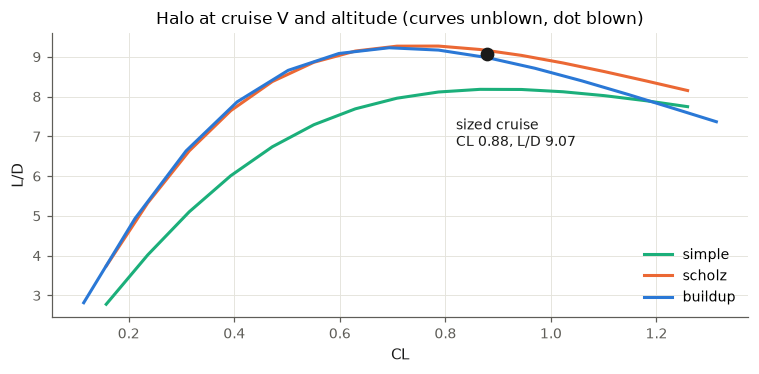

In [31]:
# L/D against CL at the cruise speed and altitude (unblown build-up, trim drag on), the sized point marked
alphas = np.linspace(-2.0, 12.0, 15)
fig, ax = plt.subplots(figsize=(7, 3.5))
for (name, model, *_), color in zip(rows, (aqua, orange, blue)):
    results = [model.evaluate(aircraft, velocity_m_s, altitude_m, x) for x in alphas]
    cl = np.array([scalar(r.cl) for r in results]); ld = np.array([scalar(r.lift_to_drag) for r in results])
    keep = cl > 0.1
    ax.plot(cl[keep], ld[keep], color=color, lw=2, label=name)
ax.plot(scalar(a.cl), scalar(a.lift_to_drag), "o", color=ink, ms=8)
ax.annotate(f"sized cruise\nCL {scalar(a.cl):.2f}, L/D {scalar(a.lift_to_drag):.2f}", (scalar(a.cl), scalar(a.lift_to_drag)),
            xytext=(-20, -60), textcoords="offset points", fontsize=9, color=ink)
ax.set_xlabel("CL"); ax.set_ylabel("L/D"); ax.set_title("Halo at cruise V and altitude (curves unblown, dot blown)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

---
## 8. How `performance/flight_point.py` calls the models

In [32]:
show_source("src/aircraft_closure/performance/flight_point.py", 181, 213)

# src/aircraft_closure/performance/flight_point.py  lines 181-213
 181      if condition.mode == "hover":
 182          alpha_deg, aero = None, None
 183          speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
 184          velocity_m_s = 0.0
 185          download_fraction = aerodynamics.hover_download_fraction(aircraft)
 186          thrust_total_N = condition.thrust_to_weight * weight_N / (1 - download_fraction)
 187      else:
 188          velocity_m_s = condition.velocity_m_s
 189          alpha_deg = opti.variable(init_guess=4.0, lower_bound=-5.0, upper_bound=20.0)
 190          speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
 191          rotor_state = None
 192          if getattr(aerodynamics, "blown_wing", None) is not None:
 193              # Tier 21 blown wing: the slipstream depends on thrust, thrust on drag. Thrust per rotor is a variable
 194              # tied to the drag by an equality below (no 

- **L181-186 hover**: no wing aerodynamics at all. The rotor thrust is T/W x W / (1 - DL/T), with DL/T from
  `hover_download_fraction(aircraft)`: a constant (simple) or geometry (Scholz, build-up).
- **L187-189 airplane mode**: alpha is an Opti variable, init 4 deg, hard bounds -5 to 20 deg.
- **L191-196**: if the model has a `blown_wing` attribute that is not None (`getattr` duck typing), the thrust per
  rotor becomes a variable inside `RotorState`, with the rotor speed variable.
- **L197-198**: one `evaluate` call: the same signature for all three models.
- **L202-205**: lift = weight x cos gamma, normalized by weight (O(1) residual), and the stall bound with the point's
  `aero` (so, for the build-up, CL <= CLmax with no extra AeroBuildup run).
- **L206-209**: cooling drag as a variable (tied to the exchanger at L383); total thrust = D + D_cooling + W sin gamma.
- **L210-212**: the blown-wing closure: n T_rotor = thrust needed, normalized by weight; thrust is then rewritten in
  terms of the rotor variable.

The trajectory (`trajectory/tiltrotor.py` L143-149) calls `evaluate` *without* a rotor state (unblown polar in
conversion), at a velocity floored at 10 m/s for the coefficients, and scales the forces with the true q.

---
## Findings

1. **Duplicate code**: `simple._surface_form_factor` (simple.py L50-53) and `scholz.form_factor_surface`
   (scholz.py L41-44) are the same expression, cited as Raymer 12.30 and Scholz 13.22 (checked above). Likewise the
   two slope methods are re-written in `buildup.py` L106-113 (identical to simple.py L105-112), and the excrescence
   guard is `_is_value` in buildup.py but inline in scholz.py L148 and L175.
2. **Dead code**: `scholz.py` L184-185, a `__main__` debug print.
3. **Docs vs code**: plan 025 "Interfaces" lists `drag_breakdown(...)` on `BuildupAerodynamics`; no such method
   exists (the breakdown is `evaluate_buildup(...).breakdown`).
4. **Positional label pairing**: `buildup.py` L140-144 pairs AeroBuildup components with labels and Q factors by
   position and `zip` truncates silently. It depends on `Aircraft.to_asb()` order (wing, h-tail, v-tail; fuselage,
   nacelles). A reordered or extra wing (a V-tail with two surfaces, a canard) would mislabel or drop items without an
   error. Same for `wings[0]` as the blown wing (L166).
5. **Form-factor Mach term at low speed**: 1.34 M^0.18 (simple and Scholz surfaces) drops below 1 under M 0.2 and to
   0 at M = 0 (0.78 at M 0.05). It is irrelevant at the Halo cruise (M 0.26, factor 1.05), but Simple/Scholz surface
   drag is under-predicted at low-speed points (a trajectory run with either model evaluates the polar down to
   10 m/s). Raymer states the term for this form; it is not meant for M near 0.
6. **Unused argument**: `SimpleAerodynamics.hover_download_fraction(aircraft)` ignores `aircraft`;
   `alpha_stall_deg(aero=...)` and `evaluate(rotor_state=...)` are accepted and ignored in Simple/Scholz. Intended
   (interchangeability), documented in the docstrings; listed so it is not mistaken for a bug.

## Gotchas

- **Three models, no base class.** Interchangeability is a naming convention (`evaluate`, `alpha_stall_deg`,
  `hover_download_fraction`, two slope methods, `cl_max`). A new model that misses one fails only when called.
- **`cl_alpha_per_rad` in the build-up result is the analytic isolated-wing slope**, not AeroBuildup's lift curve
  (4.51 /rad against AeroBuildup's whole-aircraft 5.43 /rad between 0 and 8 deg, above). It is used for the stall bound (where any positive slope gives CL <= CLmax exactly) and
  for the blown-wing swirl lift.
- **`cd0` is at the operating point.** AeroBuildup's section drag depends on alpha; "CD0" in a build-up report is not
  the zero-lift drag.
- **Excrescence and trim terms are absent, not zero, at default settings** (`_is_value`). The guard assumes the
  settings are numbers; an Opti variable would always be treated as "not the default" and add the term.
- **Trim drag uses the CG at the wing quarter root chord.** True for the Halo because the sizing constrains it there;
  for another aircraft the reference must follow the real CG.
- **The blown wing needs the rotor state.** Without `rotor_state` (the trajectory, the stall fallback) the polar is
  unblown.
- **`scalar()` on build-up results.** AeroBuildup returns 1-element arrays; after an Opti solve, re-evaluate
  numerically rather than calling `sol(...)` on the whole result dataclass.

## Limits

- Unswept surfaces only (no sweep in the form factors or Oswald factor); conventional tail only (`TailTrim` has the
  cos Gamma term, but AeroBuildup geometry is a conventional tail).
- No compressibility beyond NeuralFoil's Mach input and Korn (cruise Mach 0.26 to 0.4).
- AeroBuildup has no downwash at the tail: lift includes free-stream tail lift; only the trim moment is corrected.
- Download: no fountain, no ground effect, no fuselage or tail download; C_D,v calibrated on one aircraft.
- Blown wing: momentum theory, uniform slipstream, assumed disk position and recovery efficiency; not applied in
  conversion.
- Excrescence factor calibrated on the XV-15 at 200 kt / 20,000 ft and applied unchanged to the Halo.

## What's next (from the design log)

- Calibrate the transition location and fittings area against XV-15 flight data (plans 025, 034 "Deferred").
- V-tail, conversion segments with the blown wing (plan 025 "Deferred").
- Elevator deflection and incidence in trim (plan 036 "Deferred"; they do not change trim drag at this level).

## Review questions

<details><summary>Why does `alpha_stall_deg(aero=...)` give an exact CL <= CLmax bound even though its slope is the
analytic wing slope and not AeroBuildup's?</summary>

alpha <= alpha + (CLmax - CL)/a reduces to (CLmax - CL)/a >= 0, i.e. CL <= CLmax for any a > 0. The slope only
sets the reported stall angle, not the feasible set. It saves two AeroBuildup runs per point (370 s to about 140 s
sizing, plan 025).
</details>

<details><summary>How is the blown-wing coupling (thrust depends on drag, drag on thrust) solved without iteration?</summary>

The thrust per rotor is an Opti variable inside `RotorState` (flight_point L195-196). The aerodynamics evaluate the
blown increments as expressions of that variable, and one normalized equality n T = D + D_cooling + W sin gamma
(L210-211) closes the loop inside the same NLP.
</details>

<details><summary>Where does the excrescence factor 1.27 come from and what does it multiply?</summary>

NDARC's XV-15 cruise D/q: 6.25 ft2 for wing, tails, fuselage and pylons. AeroBuildup on the XV-15 geometry gives
4.935 ft2 for those components, so 6.25/4.935 = 1.27 (Scholz 5.344 ft2, so 1.17). It multiplies the component
profile drag including interference Q; it is added as a separate "excrescence" item of (k - 1) x that sum. Misc.
area, gear and blown increments are not scaled.
</details>

<details><summary>Why is the downwash correction needed in the trim drag, and which way does it act?</summary>

AeroBuildup has no wing downwash at the tail, so the tail sees the free-stream alpha, lifts too much and gives too
large a nose-down moment about the CG. The correction adds + V_H a_H eps with eps = 1.75 CL/(pi A), a nose-up
moment that reduces the required tail download. Without it the trim drag was about 7 % of CD at CL 0.58; with it
1.8 % (plan 036).
</details>

<details><summary>Why does DL/T not depend on thrust or density in `download.py`?</summary>

The fully developed wake velocity is 2 v_h, so the wake dynamic pressure is 2 rho v_h^2 = T/A. The download is
(T/A) C_D,v S_imm, and dividing by T leaves C_D,v S_imm / A, pure geometry plus one calibrated coefficient.
</details>

<details><summary>What does AeroBuildup give, and what does `BuildupAerodynamics` add?</summary>

AeroBuildup: whole-aircraft lift, NeuralFoil section polars (Re, Mach, post-stall), body drag with its form factors,
induced drag from the effective span, moments. Added: forced transition (TransitionAirfoil), interference Q,
excrescence, misc. area, fixed gear, k_e,F and k_e,M on the Oswald factor, blown-wing increments, trim drag from the
tail load, geometric hover download.
</details>

In [33]:
check_summary()

41 of 41 checks passed
